## Task 4

In [159]:
import numpy as np
from scipy.sparse import coo_matrix, csc_matrix
from sksparse.cholmod import cholesky
from scipy.sparse.linalg import spsolve_triangular
import time

def my_cholesky(A):
    factor = cholesky(-A, order="natural")
    return csc_matrix(factor[0])

def task4():
        
    ## matrice sparsa
    i, j, Aij = np.loadtxt("A.txt", unpack=True)
    i = i.astype(int) # coo_matrix li vuole int
    j = j.astype(int)

    n = max(i)+1 
    A = coo_matrix((Aij, (i,j)), shape=(n,n)).tocsc()

    rhs = np.loadtxt("rhs.txt")

    ## soluzione sistema e misura tempo
    start = time.time()
    Lt = my_cholesky(A)
    end = time.time()
    tempo = end - start


    # L*y = rhs
    y = spsolve_triangular(Lt.T, rhs, lower=True)
    # Lt*x = y
    x = spsolve_triangular(Lt, y, lower=False)

    return x, tempo, Lt.nnz

In [160]:
res = A @ x + rhs
print(res)

[ 0.00000000e+00  1.66533454e-16  8.32667268e-17  2.77555756e-17
 -1.73472348e-18  2.66171633e-17  2.08166817e-17  1.04083409e-17
  5.20417043e-18  3.35560572e-17 -4.81538231e-19 -6.60008073e-18
  1.38777878e-17  3.81639165e-17 -2.12503626e-17 -1.35389746e-17]


In [161]:
x, tempo, nnz = task4()
print(x,tempo, nnz)

[0.67040631 0.44215462 0.44215462 0.36082271 0.07081437 0.08275291
 0.19604945 0.1979664  0.07081437 0.08275291 0.03044727 0.06088902
 0.19604945 0.1979664  0.1301743  0.06088902] 0.0002300739288330078 58


## Task 5

In [124]:
# dati e rimappatura del vettore in uscita da task4 secondo l'ordinamento corretto
import numpy as np 

N = 4 # come task1 per ora fisso
nested_dissection = True # bool che decide l'ordinamento da usare
n, i, j, x_coord, y_coord = np.loadtxt("coords.txt", unpack=True)
T = np.zeros(len(n)) # definisco vuoto e riempio con ordinamento giusto più tardi
mmap, nmap = np.loadtxt("ordering.txt", unpack=True)
mmap = mmap.astype(int) # servono come int perché altrimenti non li accetta come indici
nmap = nmap.astype(int) 

if nested_dissection:
    # caso ordinamento nested dissection
    for k in range(len(mmap)):
        T[nmap[k]] = x[mmap[k]]
else: 
    # caso ordinamento naturale
    T = x

print(T)

[0.67040631 0.44215462 0.19604945 0.07081437 0.44215462 0.36082271
 0.1979664  0.08275291 0.19604945 0.1979664  0.1301743  0.06088902
 0.07081437 0.08275291 0.06088902 0.03044727]


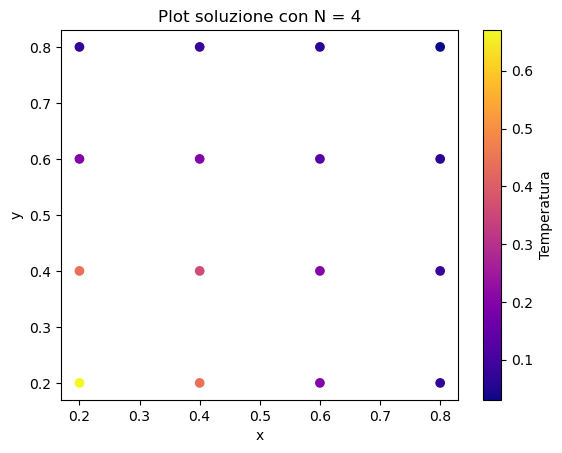

In [152]:
import matplotlib.pyplot as plt

plt.scatter(x_coord, y_coord, c=T, cmap="plasma")
plt.colorbar(label="Temperatura")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Plot soluzione con N = {N}")
plt.show()

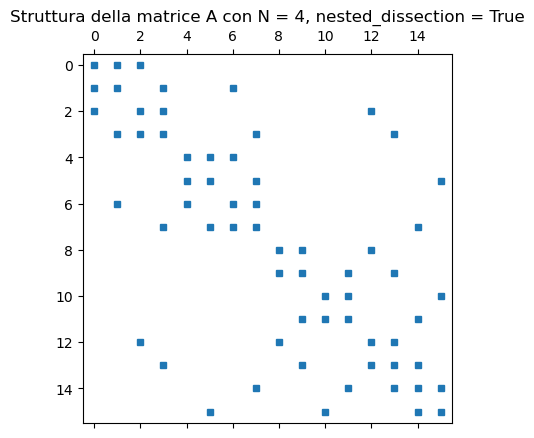

In [153]:
import matplotlib.pyplot as plt

plt.spy(A, markersize=5)
plt.title(f"Struttura della matrice A con N = {N}, nested_dissection = {nested_dissection}")
plt.show()